In this notebook, I have copied over my Linear Regression Testing, and will implement Decision Trees / Random Forest Regressors. Each of their performance will be compared using their R^2 Metric.

Below are the preprocessing steps, as per Week 3.

Testing of models, including Linear Regression, starts on Cell 16.

In [1]:
import numpy as np
import pandas as pd
import glob


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


files = glob.glob('/Users/jgd/IDXWORK/datasets/*.csv')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

rows_before_type_filter = len(df)
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

rows_removed = rows_before_type_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_type_filter:.1%}) that were not Residential/SingleFamilyResidence")

(143078, 78)
Removed 140,098 rows (49.5%) that were not Residential/SingleFamilyResidence


Making sure to filter for the features that we are interested in, not the final list of features. And then check how many are null in each column of interest.

In [2]:
cols_of_interest = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                    'LotSizeSquareFeet', 'YearBuilt', 'CloseDate', 'Latitude', 'Longitude',
                   'CountyOrParish', 'AssociationFee', 'Stories',
                   'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']

print("Number of Null Rows in each column of interest \n")
print(df[cols_of_interest].isnull().sum())

Number of Null Rows in each column of interest 

ClosePrice                   0
LivingArea                  74
BedroomsTotal                0
BathroomsTotalInteger       12
LotSizeSquareFeet         2449
YearBuilt                   88
CloseDate                    0
Latitude                    13
Longitude                   13
CountyOrParish               0
AssociationFee           41704
Stories                  14930
FireplaceYN                113
NewConstructionYN        10935
AttachedGarageYN         17299
ViewYN                   13048
PoolPrivateYN            11186
dtype: int64


Chose to drop rows with missing LivingArea, Bathrooms, Latitude, Longitude because:
1. Living Area and Square Footage vary most by location, and has a relatively low number of missing values, making imputing this data not worthwhile
2. Bathrooms also has relatively low number of missing values
3. Latitude and Longitude are needed for Geographical features, also have relatively low number of missing values

Chose to impute null YearBuilt values with median because as shown on histogram below, they tend to fall within the range of 1950 - 1975, peaking at around 1960.

**Leakage fix:** compute the median from train rows only (CloseDate < 2026-06-01) instead of the full df, so the test set's YearBuilt/Stories values never influence the imputed value.

Chose to impute AssociationFee with 0, since no data assumes no Association Fee.

Impute Stories with median, since empty doesn't imply no stories.

Impute boolean features with False - absence of data assumes feature not present.

In [3]:
rows_before_dropna = len(df)
df = df.dropna(subset=['LivingArea', 'BathroomsTotalInteger', 'Latitude', 'Longitude', 'LotSizeSquareFeet'])

train_mask = pd.to_datetime(df['CloseDate']) < '2026-06-01'

yearbuilt_median = df.loc[train_mask, 'YearBuilt'].median()
print(yearbuilt_median)

df['YearBuilt'] = df['YearBuilt'].fillna(yearbuilt_median)

df['AssociationFee'] = df['AssociationFee'].fillna(0)

stories_median = df.loc[train_mask, 'Stories'].median()
df['Stories'] = df['Stories'].fillna(stories_median)

for col in ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']:
    df[col] = df[col].fillna(False)

1976.0


In [4]:
print("After cleaning:")
print(df[cols_of_interest].isnull().sum())
print(df.shape)

rows_removed = rows_before_dropna - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_dropna:.1%}) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize")

After cleaning:
ClosePrice               0
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
LotSizeSquareFeet        0
YearBuilt                0
CloseDate                0
Latitude                 0
Longitude                0
CountyOrParish           0
AssociationFee           0
Stories                  0
FireplaceYN              0
NewConstructionYN        0
AttachedGarageYN         0
ViewYN                   0
PoolPrivateYN            0
dtype: int64
(140531, 78)
Removed 2,547 rows (1.8%) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize


Histogram in question to show how homes generally fall within said range of 1950-1970.

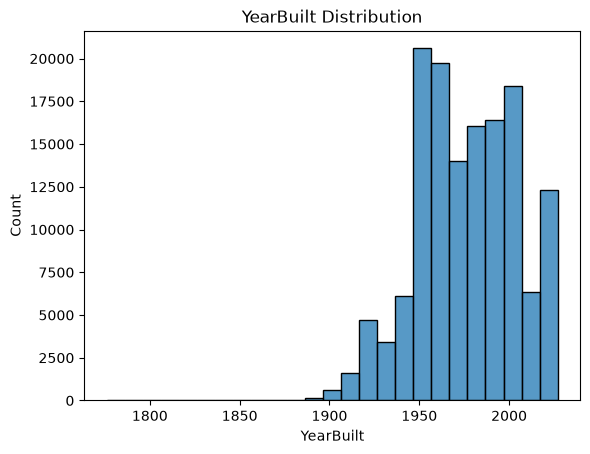

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['YearBuilt'].dropna(), bins=25)
plt.title('YearBuilt Distribution')
plt.show()

Before moving on, I want to remove the clear extreme outlier in the Glennville Area, `$900m` home. This is to prevent issues further on when using the model, since the difference in medians between the first 2 MLSAreas is `$880m`. Median prices in Malibu, the 2nd highest in the MLSAreas behind Glennville, is `$12m`. To still retain legitimate data, I will limit analysis to homes with prices over 50k and under `$15m`.

I ran into an issue because I had this cell after the test/train split, and once I wanted to use the log transform near the bottom of the notebook, I got errors that a 0 value slipped through. The bug has been fixed - R^2 score jumped from 0.3 to 0.6 after fixing this bug, without log transform.

**Best practice fix:** outlier thresholds must be learned from training data alone. Compute the 0.5th/99.5th percentile of ClosePrice using train rows only, then apply those frozen cutoffs to the whole dataset (both train and test) - never recompute percentiles on test data.

In [6]:
train_mask = pd.to_datetime(df['CloseDate']) < '2026-06-01'

closeprice_low = df.loc[train_mask, 'ClosePrice'].quantile(0.005)
closeprice_high = df.loc[train_mask, 'ClosePrice'].quantile(0.995)
print(f"Train-only ClosePrice bounds: ${closeprice_low:,.0f} - ${closeprice_high:,.0f}")

rows_before_price_filter = len(df)
df = df[(df['ClosePrice'] >= closeprice_low) & (df['ClosePrice'] <= closeprice_high)]

rows_removed = rows_before_price_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_price_filter:.1%}) outside the train-only ClosePrice bounds")

Train-only ClosePrice bounds: $185,000 - $8,929,537
Removed 1,393 rows (1.0%) outside the train-only ClosePrice bounds


Setting test/train splits for the model.

In [7]:
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

test = df[df['CloseDate'] >= '2026-06-01']
train = df[df['CloseDate'] < '2026-06-01']

print(train.shape)
print(test.shape)

(126637, 78)
(12501, 78)


Additionally checking County or Parish.

In [8]:
print(df.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(20))
print(df['CountyOrParish'].nunique())

CountyOrParish
San Mateo          2025000.0
Mono               1910000.0
Santa Clara        1880000.0
Orange             1400000.0
Santa Cruz         1350000.0
San Francisco      1350000.0
Alameda            1300000.0
Marin              1260000.0
San Diego          1060000.0
Los Angeles        1010000.0
Ventura             965000.0
Monterey            956000.0
San Luis Obispo     939495.0
Contra Costa        899000.0
Napa                878500.0
San Benito          782500.0
Sonoma              770000.0
Santa Barbara       765000.0
El Dorado           760000.0
Placer              673750.0
Name: ClosePrice, dtype: float64
60


CountyOrParish has 60 which is more manageable for encoding, hence why I chose it over the other location metrics.

In [9]:
numerical_features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                      'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude',
                      'AssociationFee', 'Stories']

boolean_features = ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN',
                    'ViewYN', 'PoolPrivateYN']

categorical_features = ['CountyOrParish']
target = 'ClosePrice'

features = numerical_features + boolean_features + categorical_features

## Feature Selection Reasoning

**Physical characteristics** (`LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger`, `LotSizeSquareFeet`, `Stories`) **and location** (`Latitude`, `Longitude`, `CountyOrParish`): known-before-sale facts with empirically-supported relationships to price.

**Boolean features** such as `FireplaceYN` and others were selected using empirical information, and whether or not it would make sense for the feature to impact price.

Below here, I am doing some additional checking for extreme outliers to filter out. Brought to my attention by my groupmates in DS55.

In [10]:
numeric_cols = numerical_features
print(df[numeric_cols].describe())

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  139138.000000  139138.000000          139138.000000       1.391380e+05   
mean     2032.042511       3.492648               2.618559       3.711784e+05   
std       950.640402       0.947173               1.073202       1.740497e+07   
min         0.000000       0.000000               0.000000       0.000000e+00   
25%      1390.000000       3.000000               2.000000       5.663000e+03   
50%      1822.000000       3.000000               2.000000       7.260000e+03   
75%      2437.000000       4.000000               3.000000       1.041875e+04   
max     17153.000000      22.000000              35.000000       1.938943e+09   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  139138.000000  139138.000000  139138.000000   139138.000000   
mean     1975.832885      34.763621    -118.627055       73.254855   
std        27.580842       1.765061       3.264729      274.

Latitude and Longitude bounds for California (inspired by Kelvin).

LivingArea must be positive non-zero number to be seriously considered.

Reasonable caps for both bedrooms and bathrooms, captures legit values while removing extreme outliers.

LotSize cap of 10 acres = 435,600 sqft, reasonable bound accounts for large lots and filters bad data.

**Leakage fix:** the block above only ever reassigns `df`, but `train`/`test` were already sliced off as separate DataFrames earlier (test/train split cell), so these bounds never actually reached the modeling data. Applying the same fixed bounds directly to train/test here so the outliers are actually removed from what the model trains/evaluates on.

In [11]:
df = df[
    (df['Latitude'] >= 32.5) & (df['Latitude'] <= 42.5) &
    (df['Longitude'] >= -124.5) & (df['Longitude'] <= -114.5)
]

df = df[df['LivingArea'] > 0]

df = df[(df['BedroomsTotal'] <= 15) & (df['BathroomsTotalInteger'] <= 15)]

df = df[df['LotSizeSquareFeet'] <= 435600]

train_before = len(train)
test_before = len(test)

train = train[
    (train['Latitude'] >= 32.5) & (train['Latitude'] <= 42.5) &
    (train['Longitude'] >= -124.5) & (train['Longitude'] <= -114.5)
]
test = test[
    (test['Latitude'] >= 32.5) & (test['Latitude'] <= 42.5) &
    (test['Longitude'] >= -124.5) & (test['Longitude'] <= -114.5)
]

train = train[train['LivingArea'] > 0]
test = test[test['LivingArea'] > 0]

train = train[(train['BedroomsTotal'] <= 15) & (train['BathroomsTotalInteger'] <= 15)]
test = test[(test['BedroomsTotal'] <= 15) & (test['BathroomsTotalInteger'] <= 15)]

train = train[train['LotSizeSquareFeet'] <= 435600]
test = test[test['LotSizeSquareFeet'] <= 435600]

print(train.shape)
print(test.shape)

train_removed = train_before - len(train)
test_removed = test_before - len(test)
print(f"Removed {train_removed:,} train rows ({train_removed / train_before:.1%}) and {test_removed:,} test rows ({test_removed / test_before:.1%}) as lat/long/size outliers")

(125795, 78)
(12408, 78)
Removed 842 train rows (0.7%) and 93 test rows (0.7%) as lat/long/size outliers


After fully filtering for bad values, we have around 138000 points of data to analyse.

After filtering, 97% of rows remain, good retention.

In [12]:
print(df[numerical_features + ['ClosePrice']].describe())

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  138203.000000  138203.000000          138203.000000      138203.000000   
mean     2028.997582       3.492471               2.615681       14804.475432   
std       943.160390       0.940914               1.063569       33590.953886   
min       100.000000       0.000000               0.000000           0.000000   
25%      1390.000000       3.000000               2.000000        5663.000000   
50%      1820.000000       3.000000               2.000000        7241.000000   
75%      2434.000000       4.000000               3.000000       10256.000000   
max     17153.000000      15.000000              15.000000      435600.000000   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  138203.000000  138203.000000  138203.000000   138203.000000   
mean     1975.771821      34.763854    -118.664024       72.932597   
std        27.578553       1.689099       1.846655      271.

In [13]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

Get cleaned data and preprocess it, by encoding categorical features and scaling numerical values.

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features + boolean_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(125795, 73)
(12408, 73)


Linear Regression model implementation.

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](73,)","[ 522285.3 , -136405.08, 237930.73,...,-1708797.96, 282572.97, 674485.82]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.364e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,73


In [16]:
feature_names = numerical_features + boolean_features + categorical_features
for name, coef in zip(feature_names, model.coef_[:len(numerical_features + boolean_features)]):
    print(f"{name}: {coef:.2f}")

LivingArea: 522285.30
BedroomsTotal: -136405.08
BathroomsTotalInteger: 237930.73
LotSizeSquareFeet: -24212.02
YearBuilt: -105099.65
Latitude: -1241750.00
Longitude: -616674.07
AssociationFee: 49484.17
Stories: -90293.39
FireplaceYN: 24984.71
NewConstructionYN: 28970.59
AttachedGarageYN: -32535.74
ViewYN: 41230.99
PoolPrivateYN: 9291.23


Strange how Bedrooms, Year, Stories, Pools, Fireplaces have negative coefficients.

**Baseline R² score = 0.6428**

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

y_pred = model.predict(X_test_processed)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test))

print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.0f}")
print(f"MAPE: {mape:.2%}")
print(f"MdAPE: {mdape:.2%}")

R² Score: 0.6428
MAE: $369,580
MAPE: 34.50%
MdAPE: 25.78%


My teammates mentioned log transform, so I wanted to try it out since ClosePrice is skewed right. [Question]: Would it be possible to use log transform on other features that are skewed right? worth considering. NOT BASELINE R^2 SCORE, but R^2 here = 0.7688, a clear increase compared to Baseline score.

**Note:** predictions are back-transformed to dollar scale so MAE/MAPE/MdAPE reflect real price error, not log-price error - MAPE/MdAPE/MAE should be comparable directly against the baseline model.

In [18]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model_log = LinearRegression()
model_log.fit(X_train_processed, y_train_log)

y_pred_log = model_log.predict(X_test_processed)
r2_log = r2_score(y_test_log, y_pred_log)
print(f"Log-transformed R²: {r2_log:.4f}")

y_pred_dollars = np.exp(y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_dollars)
mape_log = mean_absolute_percentage_error(y_test, y_pred_dollars)
mdape_log = np.median(np.abs((y_test - y_pred_dollars) / y_test))

print(f"MAE (back-transformed): ${mae_log:,.0f}")
print(f"MAPE (back-transformed): {mape_log:.2%}")
print(f"MdAPE (back-transformed): {mdape_log:.2%}")

Log-transformed R²: 0.7688
MAE (back-transformed): $333,237
MAPE (back-transformed): 23.19%
MdAPE (back-transformed): 17.63%


Implementation of Decision Tree.

First, check R^2 when max_depth = 2.

**Honest mistake here** - commented out all code in this cell because I accidentally used test data, which is supposed to remain unseen when fine-tuning the decision tree. This introduced leakage, but it's resolved in the cell below.

In [19]:
#from sklearn.tree import DecisionTreeRegressor

#dt_model = DecisionTreeRegressor(max_depth=2, random_state=42)
#dt_model.fit(X_train_processed, y_train)

#y_pred_dt = dt_model.predict(X_test_processed)
#r2_dt = r2_score(y_test, y_pred_dt)
#print(f"Decision Tree R²: {r2_dt:.4f}")

Implementation of Decision Tree.

Checking multiple different depths for tree, to see which I want to use. Using on train data this time, avoiding leakage.

**Best practice fix:** previously, cross_val_score was run on X_train_processed - data that had already been scaled and encoded using the full training set. This means the held-out fold in each CV round had already influenced the scaler, which is a form of leakage. The fix: wrap preprocessing and model in a Pipeline and pass raw X_train instead. Now the scaler and encoder refit inside each fold using only that fold's training rows, keeping the validation portion truly unseen.

After looking at the depths, the R² plateaus at 0.7750 @ depth 15, with a standard deviation of 0.0138.

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

depths = [2, 5, 8, 10, 12, 15, 20]
for depth in depths:
    dt_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=depth, random_state=42))
    ])
    cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=5, scoring='r2')
    print(f"Depth {depth}: CV R²={cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Depth 2: CV R²=0.3510 (+/- 0.0129)


Depth 5: CV R²=0.5514 (+/- 0.0100)


Depth 8: CV R²=0.7041 (+/- 0.0088)


Depth 10: CV R²=0.7547 (+/- 0.0109)


Depth 12: CV R²=0.7726 (+/- 0.0105)


Depth 15: CV R²=0.7750 (+/- 0.0138)


Depth 20: CV R²=0.7671 (+/- 0.0110)


In [21]:

dt_final = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_final.fit(X_train_processed, y_train)

y_pred_dt = dt_final.predict(X_test_processed)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
mdape_dt = np.median(np.abs((y_test - y_pred_dt) / y_test))

print(f"Decision Tree (depth 15) R²: {r2_dt:.4f}")
print(f"MAE: ${mae_dt:,.0f}")
print(f"MAPE: {mape_dt:.2%}")
print(f"MdAPE: {mdape_dt:.2%}")

Decision Tree (depth 15) R²: 0.7839
MAE: $226,660
MAPE: 17.04%
MdAPE: 11.25%


I gave this cell 20 minutes to run, wasn't seeing any progress, machine couldn't handle it. I commented this code out, and in the next cell, changes will be made so I could legitimately test it within the bounds of my system's performance.

In [22]:
#from sklearn.ensemble import RandomForestRegressor

#rf_final = RandomForestRegressor(random_state=42)
#rf_final.fit(X_train_processed, y_train)

#y_pred_rf = rf_final.predict(X_test_processed)
# same r2_score / mean_absolute_error / mean_absolute_percentage_error / MdAPE calls as before

The changes made in order to run the random forest regressors. Limited depth to 15 because that's what worked for the decision trees, and for compatibility's sake.

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_final.fit(X_train_processed, y_train)

y_pred_rf = rf_final.predict(X_test_processed)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
mdape_rf = np.median(np.abs((y_test - y_pred_rf) / y_test))

print(f"Random Forest R²: {r2_rf:.4f}")
print(f"MAE: ${mae_rf:,.0f}")
print(f"MAPE: {mape_rf:.2%}")
print(f"MdAPE: {mdape_rf:.2%}")

Random Forest R²: 0.8611
MAE: $190,934
MAPE: 14.93%
MdAPE: 9.85%


Model comparison summary - Week 5 deliverable.

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Log-transformed Linear Regression', 'Decision Tree (depth 15)', 'Random Forest (100 trees, depth 15)'],
    'R2': [r2, r2_log, r2_dt, r2_rf],
    'MAE': [mae, mae_log, mae_dt, mae_rf],
    'MAPE': [mape, mape_log, mape_dt, mape_rf],
    'MdAPE': [mdape, mdape_log, mdape_dt, mdape_rf],
})

comparison['R2'] = comparison['R2'].map(lambda x: f"{x:.4f}")
comparison['MAE'] = comparison['MAE'].map(lambda x: f"${x:,.0f}")
comparison['MAPE'] = comparison['MAPE'].map(lambda x: f"{x:.2%}")
comparison['MdAPE'] = comparison['MdAPE'].map(lambda x: f"{x:.2%}")

comparison

,Model,R2,MAE,MAPE,MdAPE
0,Linear Regression,0.6428,"$369,580",34.50%,25.78%
1,Log-transformed Linear Regression,0.7688,"$333,237",23.19%,17.63%
2,Decision Tree (depth 15),0.7839,"$226,660",17.04%,11.25%
3,"Random Forest (100 trees, depth 15)",0.8611,"$190,934",14.93%,9.85%


## Model Comparison

| Model | R² | MAE | MAPE | MdAPE |
|---|---|---|---|---|
| Linear Regression | 0.6428 | `$369,580` | 34.50% | 25.78% |
| Log-transformed Linear Regression | 0.7688 | `$333,237` | 23.19% | 17.63% |
| Decision Tree (depth 15) | 0.7839 | `$226,660` | 17.04% | 11.25% |
| Random Forest (100 trees, depth 15) | 0.8611 | `$190,934` | 14.93% | 9.85% |

In [25]:
#Start of Week 6 Work

#Feature Engineering

# Bed/bath ratio, NaN to prevent issues with division
# BedBathRatio: captures the relationship between bedroom and bathroom counts. 
# A home with many bedrooms but few bathrooms is functionally different from a balanced one

train['BedBathRatio'] = train['BedroomsTotal'] / train['BathroomsTotalInteger'].replace(0, np.nan)
test['BedBathRatio'] = test['BedroomsTotal'] / test['BathroomsTotalInteger'].replace(0, np.nan)

# Property age at time of sale (instead of raw YearBuilt)
# PropertyAge: reframes YearBuilt as just an age, which is more directly interpretable by the model
train['PropertyAge'] = train['CloseDate'].dt.year - train['YearBuilt']
test['PropertyAge'] = test['CloseDate'].dt.year - test['YearBuilt']

# Bedroom / living area ratio
# BedroomAreaRatio — captures how spacious or cramped a home's bedrooms are relative to its total size,
# a new piece of information gathered from BedroomsTotal and LivingArea
train['BedroomAreaRatio'] = train['BedroomsTotal'] / train['LivingArea']
test['BedroomAreaRatio'] = test['BedroomsTotal'] / test['LivingArea']

#Look to add some of my teammates features, if they interest me


In [26]:
import geopandas as gpd

# I realized that I needed to get the GeoJSON, but I accidentally did the .shp instead
# Doesn't impact anything
districts = gpd.read_file('/Users/jgd/IDXWORK/datasets/geographical/DistrictAreas2526_6284572545507999242/DistrictAreas2526.shp')

print(districts['DistrictTy'].unique())
print(len(districts))


districts = districts[districts['DistrictTy'] == 'Unified']

print(districts.columns.tolist())
print(districts.crs)
print(districts.head())

<ArrowStringArray>
['Unified', 'Elementary', 'High']
Length: 3, dtype: str
936
['Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictNa', 'DistrictTy', 'GradeLow', 'GradeHigh', 'GradeLowCe', 'GradeHighC', 'AssistStat', 'UpdateNote', 'EnrollTota', 'EnrollChar', 'EnrollNonC', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAre', 'LocaleCode', 'LocaleDesc', 'geometry']
EPSG:3857
      Year    FedID   CDCode         CDSCode CountyName  \
0  2025-26  0601770  0161119  01611190000000    Alameda   
1  2025-26  0601860  0161127  01611270000000    Alameda   
2  2025-26  0604740  0161143  01611430000000    Alameda   
3  2025-26  0607800  0161150  01611500000000    Alameda   
4  2025-26  0612630  0161168  01611680000000    

In [27]:
# Switching coordinate systems to longitude / latitude to align with our columns
districts = districts.to_crs(epsg=4326)
print(districts.crs)

EPSG:4326


In [28]:
#
train_geo = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train['Longitude'], train['Latitude']),
    crs='EPSG:4326'
)

test_geo = gpd.GeoDataFrame(
    test,
    geometry=gpd.points_from_xy(test['Longitude'], test['Latitude']),
    crs='EPSG:4326'
)

#geometry holds the boundaries for the districts

train = gpd.sjoin(train_geo, districts[['DistrictNa', 'DistrictTy', 'geometry']], how='left', predicate='within')
test = gpd.sjoin(test_geo, districts[['DistrictNa', 'DistrictTy', 'geometry']], how='left', predicate='within')


#Dropping index_right because its only a book keeping column made by the sjoin,
#Not needed for model right now so dropping it 
#We already get all that information from the distrcitna , type, geometry

train = train.drop(columns='index_right')
test = test.drop(columns='index_right')

print(train['DistrictNa'].isnull().sum(), 'unmatched rows in train')
print(test['DistrictNa'].isnull().sum(), 'unmatched rows in test')

30086 unmatched rows in train
3030 unmatched rows in test


In [29]:
# I did 250 minimum here because I wanted a number of districts kept comparable to the number of
# counties, which was relevant for the other geographical feature
# this can lead to some loss of detail though, since all districts that don't meet the count
# simply get placed into an other column

# could be worth testing different counts and seeing their r^2 values

district_counts = train['DistrictNa'].value_counts()
keep_districts = district_counts[district_counts >= 250].index

train['DistrictGrouped'] = train['DistrictNa'].where(train['DistrictNa'].isin(keep_districts), 'Other')
test['DistrictGrouped'] = test['DistrictNa'].where(test['DistrictNa'].isin(keep_districts), 'Other')

print(len(keep_districts), 'districts kept')

96 districts kept


In [30]:
# Adding cyclical month feature as per best practice manual 
    
# Cyclical month encoding — captures seasonality without an artificial December-to-January jump
train['CloseMonthSin'] = np.sin(2 * np.pi * train['CloseDate'].dt.month / 12)
train['CloseMonthCos'] = np.cos(2 * np.pi * train['CloseDate'].dt.month / 12)

test['CloseMonthSin'] = np.sin(2 * np.pi * test['CloseDate'].dt.month / 12)
test['CloseMonthCos'] = np.cos(2 * np.pi * test['CloseDate'].dt.month / 12)

In [31]:
numerical_features = numerical_features + ['BedBathRatio', 'PropertyAge', 'BedroomAreaRatio'] + ['CloseMonthSin', 'CloseMonthCos']
categorical_features = categorical_features + ['DistrictGrouped']
features = numerical_features + boolean_features + categorical_features

In [32]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features + boolean_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(125795, 175)
(12408, 175)


In [33]:
# In attemtping to run the linear regression in the cell below, I got an error about NaN values,
# And I suspect that is related to the feature I engineered, being the bed/bath ratio and division by 0
# If there is division by 0 present, the column bed/bath ratio gets a NaN value

print(train['BedBathRatio'].isnull().sum())
print(train['PropertyAge'].isnull().sum())
print(train['BedroomAreaRatio'].isnull().sum())

# from earlier, the values in bedbathration that end up with NaN due to division by 0 will ge imputed by
# the median, because both bedrooms and bathrooms are right skewed distributions

bedbathratio_median = train['BedBathRatio'].median()
train['BedBathRatio'] = train['BedBathRatio'].fillna(bedbathratio_median)
test['BedBathRatio'] = test['BedBathRatio'].fillna(bedbathratio_median)


25
0
0


In [34]:
#Same Code as 2 cells above, just with updated bed bath ratio to prevent errors with NaN

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features + boolean_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(125795, 175)
(12408, 175)


In [35]:
# Testing the Models with New Geographic Data and New Feature Set

# Baseline linear regression
model_v2 = LinearRegression()
model_v2.fit(X_train_processed, y_train)
y_pred_v2 = model_v2.predict(X_test_processed)
r2_v2 = r2_score(y_test, y_pred_v2)
mae_v2 = mean_absolute_error(y_test, y_pred_v2)
mape_v2 = mean_absolute_percentage_error(y_test, y_pred_v2)
mdape_v2 = np.median(np.abs((y_test - y_pred_v2) / y_test))

In [36]:
# Log-transformed linear regression
y_train_log_v2 = np.log(y_train)
y_test_log_v2 = np.log(y_test)
model_log_v2 = LinearRegression()
model_log_v2.fit(X_train_processed, y_train_log_v2)
y_pred_log_v2 = model_log_v2.predict(X_test_processed)
y_pred_dollars_v2 = np.exp(y_pred_log_v2)
r2_log_v2 = r2_score(y_test_log_v2, y_pred_log_v2)
mae_log_v2 = mean_absolute_error(y_test, y_pred_dollars_v2)
mape_log_v2 = mean_absolute_percentage_error(y_test, y_pred_dollars_v2)
mdape_log_v2 = np.median(np.abs((y_test - y_pred_dollars_v2) / y_test))

In [37]:
# Decision Tree (same depth=15 as Week 5)
dt_final_v2 = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_final_v2.fit(X_train_processed, y_train)
y_pred_dt_v2 = dt_final_v2.predict(X_test_processed)
r2_dt_v2 = r2_score(y_test, y_pred_dt_v2)
mae_dt_v2 = mean_absolute_error(y_test, y_pred_dt_v2)
mape_dt_v2 = mean_absolute_percentage_error(y_test, y_pred_dt_v2)
mdape_dt_v2 = np.median(np.abs((y_test - y_pred_dt_v2) / y_test))

In [38]:
# Random Forest (same settings as Week 5 choice)
rf_final_v2 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_final_v2.fit(X_train_processed, y_train)
y_pred_rf_v2 = rf_final_v2.predict(X_test_processed)
r2_rf_v2 = r2_score(y_test, y_pred_rf_v2)
mae_rf_v2 = mean_absolute_error(y_test, y_pred_rf_v2)
mape_rf_v2 = mean_absolute_percentage_error(y_test, y_pred_rf_v2)
mdape_rf_v2 = np.median(np.abs((y_test - y_pred_rf_v2) / y_test))

In [39]:

week6_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Log-transformed Linear Regression', 'Decision Tree (depth 15)', 'Random Forest (100 trees, depth 15)'],
    'R2 (Week 5)': [r2, r2_log, r2_dt, r2_rf],
    'R2 (Week 6)': [r2_v2, r2_log_v2, r2_dt_v2, r2_rf_v2],
    'MAE (Week 5)': [mae, mae_log, mae_dt, mae_rf],
    'MAE (Week 6)': [mae_v2, mae_log_v2, mae_dt_v2, mae_rf_v2],
    'MAPE (Week 5)': [mape, mape_log, mape_dt, mape_rf],
    'MAPE (Week 6)': [mape_v2, mape_log_v2, mape_dt_v2, mape_rf_v2],
    'MdAPE (Week 5)': [mdape, mdape_log, mdape_dt, mdape_rf],
    'MdAPE (Week 6)': [mdape_v2, mdape_log_v2, mdape_dt_v2, mdape_rf_v2],
})

week6_comparison

,Model,R2 (Week 5),R2 (Week 6),MAE (Week 5),MAE (Week 6),MAPE (Week 5),MAPE (Week 6),MdAPE (Week 5),MdAPE (Week 6)
0,Linear Regression,0.642781,0.690128,369580.154678,332995.528388,0.344989,0.303503,0.257811,0.219814
1,Log-transformed Linear Regression,0.768758,0.814687,333237.137136,285856.647879,0.231897,0.202893,0.176257,0.146538
2,Decision Tree (depth 15),0.783925,0.757747,226660.254116,239686.737086,0.170404,0.181367,0.112509,0.118269
3,"Random Forest (100 trees, depth 15)",0.861051,0.856809,190934.333030,197695.089079,0.149346,0.157561,0.098511,0.102295


## Week 6 Feature Engineering: Model Behavior

Feature set added: `BedBathRatio`, `PropertyAge`, `BedroomAreaRatio`, `DistrictGrouped`, `CloseMonthSin`, `CloseMonthCos`

| Model | R2 (Week 5) | R2 (Week 6) | MAE (Week 5) | MAE (Week 6) | MAPE (Week 5) | MAPE (Week 6) | MdAPE (Week 5) | MdAPE (Week 6) |
|---|---|---|---|---|---|---|---|---|
| Linear Regression | 0.6428 | 0.6901 | `$369,580` | `$332,996` | 34.50% | 30.35% | 25.78% | 21.98% |
| Log-transformed Linear Regression | 0.7688 | 0.8147 | `$333,237` | `$285,857` | 23.19% | 20.29% | 17.63% | 14.65% |
| Decision Tree (depth 15) | 0.7839 | 0.7577 | `$226,660` | `$239,687` | 17.04% | 18.14% | 11.25% | 11.83% |
| Random Forest (100 trees, depth 15) | 0.8611 | 0.8568 | `$190,934` | `$197,695` | 14.93% | 15.76% | 9.85% | 10.23% |

Linear models improved across every metric. Linear Regression gained about 0.047 R2 and closed nearly 4 points of MdAPE; the log-transformed version gained about 0.046 R2 and closed about 3 points of MdAPE. Linear regression cannot discover interactions or ratios on its own, so handing it explicit non-linear combinations (BedBathRatio, BedroomAreaRatio) and finer location detail (DistrictGrouped) gave it real, exploitable signal it could not build on its own.

Tree-based models were slightly worse across every metric. Decision Tree dropped about 0.026 R2, Random Forest dropped about 0.004 R2.

Cyclical month encoding (CloseMonthSin/CloseMonthCos) contributed only marginally to these results. With roughly one year of training data, the model has just one example of each month's seasonal pattern to learn from, which limits how much a genuine seasonal effect can be distinguished from one-off noise in a single year. This feature was included primarily for consistency with the rest of the team's approach.

Both tree models still use max_depth=15, which was tuned via cross-validation for the Week 5 feature set, before DistrictGrouped added roughly 96 new one-hot columns. Could possibly be worth testing new numbers of depths given that there are new features?

Bottom line: Week 6 features are a clear improvement for both linear models, and roughly neutral for the tree-based models.

In [40]:
# Save the enriched dataset (with all Week 6 features) for use throughout the rest of the project
train.drop(columns='geometry').to_csv('/Users/jgd/IDXWORK/datasets/enriched/enriched_train.csv', index=False)
test.drop(columns='geometry').to_csv('/Users/jgd/IDXWORK/datasets/enriched/enriched_test.csv', index=False)

print("Enriched train/test datasets saved")

Enriched train/test datasets saved
